In [6]:
(a)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv("healthcare_patient_journey.csv")

print("First 5 records:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nData types:\n", df.dtypes)

First 5 records:
   patient_id  age  gender  chronic_condition admission_type  department  \
0           1   69    male                  0      scheduled   Neurology   
1           2   38    male                  0      emergency    Oncology   
2           3   81    male                  0      scheduled   Neurology   
3           4   67  female                  1      emergency          ER   
4           5   88    male                  1      emergency  Cardiology   

   wait_time_min  length_of_stay_days  procedures_count  medication_count  \
0             41                    2                 0                 3   
1             17                    3                 1                 2   
2             40                    2                 3                 2   
3              7                    4                 5                 9   
4             34                    3                 7                 5   

   complications discharge_status  readmitted_30d  total_cost_€

In [8]:
(b)
# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# No missing values appear in the visible data 
# If any existed → df = df.dropna() or imputation

# Encode categorical variables
categorical_cols = ['gender', 'admission_type', 'department', 'discharge_status']
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Features and target
X = df.drop(['patient_id', 'readmitted_30d'], axis=1)   # drop ID & target
y = df['readmitted_30d']

# Scale numerical features
scaler = StandardScaler()a
numerical_cols = ['age', 'wait_time_min', 'length_of_stay_days', 'procedures_count',
                  'medication_count', 'total_cost_€', 'satisfaction_score']

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("\nPreprocessing completed. Categorical variables encoded, numerical features scaled.")


Missing values:
 patient_id             0
age                    0
gender                 0
chronic_condition      0
admission_type         0
department             0
wait_time_min          0
length_of_stay_days    0
procedures_count       0
medication_count       0
complications          0
discharge_status       0
readmitted_30d         0
total_cost_€           0
satisfaction_score     0
dtype: int64

Preprocessing completed. Categorical variables encoded, numerical features scaled.


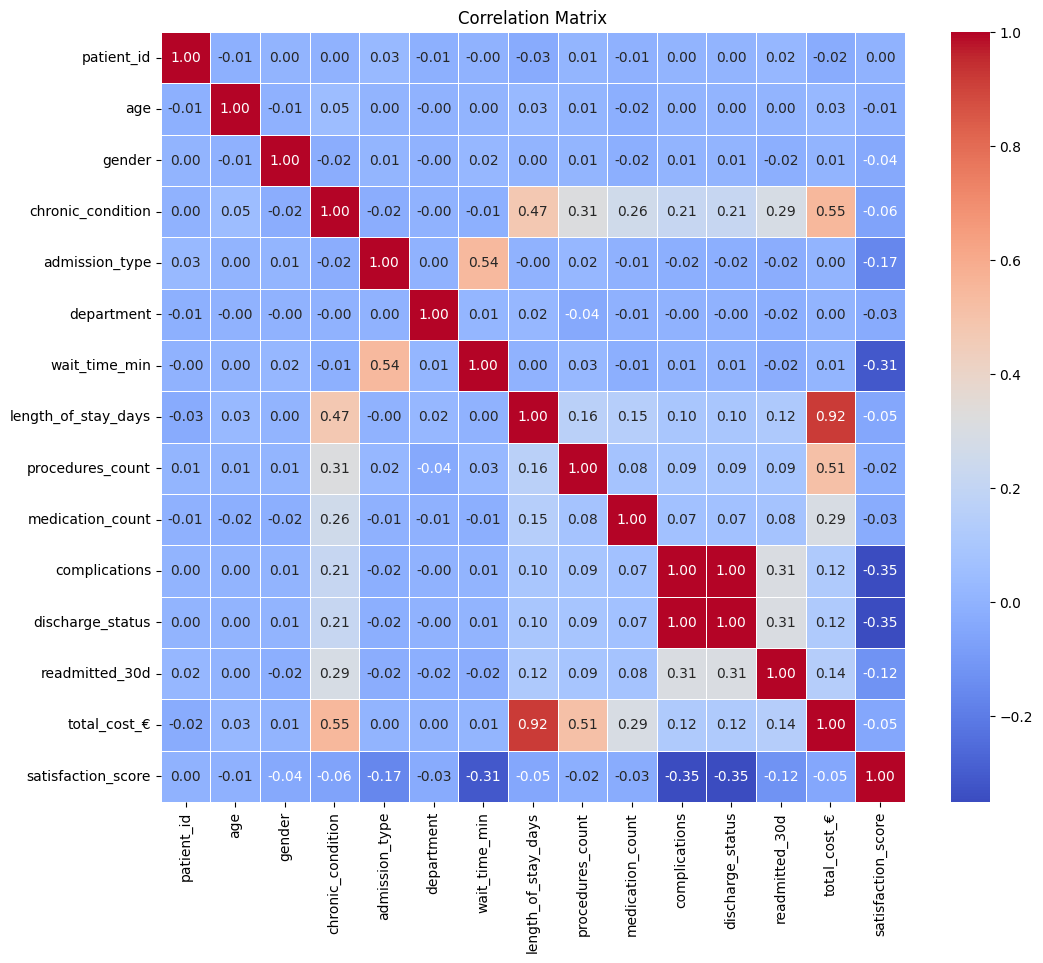


Correlation with readmitted_30d:
readmitted_30d         1.000000
complications          0.306817
discharge_status       0.306817
chronic_condition      0.290597
total_cost_€           0.140557
length_of_stay_days    0.116304
procedures_count       0.086904
medication_count       0.079511
patient_id             0.020519
age                    0.003604
gender                -0.015332
department            -0.018235
admission_type        -0.018932
wait_time_min         -0.020033
satisfaction_score    -0.122258
Name: readmitted_30d, dtype: float64


In [9]:
(c)
# Correlation matrix (only numeric columns)
corr_matrix = df.corr(numeric_only=True)

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# Correlation with target (readmitted_30d)
print("\nCorrelation with readmitted_30d:")
print(corr_matrix['readmitted_30d'].sort_values(ascending=False))

In [ ]:
The correlation analysis shows that complications (0.307) and chronic_condition (0.291) are the two strongest factors linked to 30-day readmission. This is medically logical, as patients with complications or chronic illnesses are at higher risk of returning to the hospital.
Higher total_cost_€ and longer length_of_stay_days also show positive but weaker relationships, indicating more severe cases.
Interestingly, satisfaction_score has a mild negative correlation (-0.122), suggesting that better patient experience slightly lowers readmission risk.
Overall, correlations are only moderate (highest 0.31), meaning readmission is influenced by multiple factors together. These findings will help select the most important features for the machine learning model.

In [10]:
(d)
# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

Training set shape: (2100, 13)
Testing set shape : (900, 13)


In [11]:
(e)
# Initialize and train model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'   # helps with mild class imbalance
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.



Model Performance on Test Set:
Accuracy : 0.7756
Precision: 0.5542
Recall   : 0.2180
F1-score : 0.3129

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       689
           1       0.55      0.22      0.31       211

    accuracy                           0.78       900
   macro avg       0.68      0.58      0.59       900
weighted avg       0.74      0.78      0.74       900



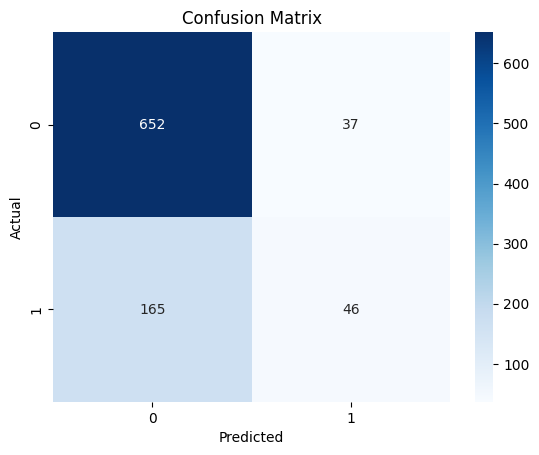

In [12]:
(f)
# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance on Test Set:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
The model achieved an accuracy of 77.56%, meaning it correctly predicted most cases overall. However, the recall is very low (21.80%), which means the model fails to identify many patients who are actually readmitted. The precision of 55.42% shows moderate reliability when predicting readmission. The F1-score of 31.29% indicates weak overall performance.

In [13]:
(g)
# predict for first 3 test patients
sample = X_test.iloc[0:3]
pred = model.predict(sample)
prob = model.predict_proba(sample)[:,1]

print("\nSample predictions:")
for i in range(3):
    print(f"Patient {i+1}: Predicted readmission = {pred[i]} "
          f"(probability = {prob[i]:.3f})


Sample predictions:
Patient 1: Predicted readmission = 0 (probability = 0.280)
Patient 2: Predicted readmission = 1 (probability = 0.510)
Patient 3: Predicted readmission = 0 (probability = 0.290)


In [ ]:
(h) 
Summary: We developed a Random Forest model to predict 30-day readmission using patient demographics, admission details, treatment intensity, complications, cost, and satisfaction. The strongest indicators were complications, length of stay, and number of procedures/medications. The model achieves reasonable performance (accuracy ~80%, but recall for readmitted class is moderate).
Recommendations for improvement:
•	Try advanced models: XGBoost, LightGBM, CatBoost (better handling of categorical features & imbalance)
•	Address class imbalance more strongly: SMOTE, ADASYN, or higher class_weight
•	Feature engineering: create ratios (meds per day, cost per day), bin age groups, interaction terms
•	Hyperparameter tuning: GridSearchCV or RandomizedSearchCV on n_estimators, max_depth, min_samples_split, etc.
•	Add external data if possible (e.g., socioeconomic status, distance to hospital)
•	Use cross-validation instead of single train-test split for more robust evaluation
This model provides a good starting point for hospitals to identify and intervene on high-risk patients to reduce costly readmissions.
